# CRM Assemblage Efficiency 

In [1]:
import sys, os, time
sys.path.insert(0, r'd:\prebiotic_crm\scripts')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import crm_simulation as crm

sns.set_style('ticks')
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.fontsize': 11,
})

# Frequently used module constants
K_B, T_K, TAU0, MS = crm.K_B, crm.T_K, crm.TAU0, crm.MS
kT    = K_B * T_K
SIZES = crm.SIZES

PLOTS_DIR = r'd:\prebiotic_crm\plots_crm_efficiency_mc'
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f'SIZES: {len(SIZES)} steps, {SIZES[0]}-{SIZES[-1]} nm')


SIZES: 59 steps, 20-200 nm


## 1. Exact Markov-chain state distributions

For growth time = 1 day and $B = 30 uT (matching
`crm_efficiency_final.ipynb`'s reference field), the master equation is
integrated through the full growth path for `N_ORIENT_MC` Fibonacci-sphere
crystal orientations via `crm.run_single_orientation_final_probs`.

**Fine grid**: the integration now steps through a 1 nm-spaced grid
(20-200 nm, 181 steps) built by `crm.build_fine_grid` — polynomial-fit
barriers and linearly-interpolated moment fractions from the raw MERRILL
hist files.

In [ ]:
# -- Fine-grid setup: polynomial-interpolated barriers on a 1 nm grid --------
# N_ORIENT_MC    = 1500
N_ORIENT_MC    = 5000
GROWTH_TIME_MC = 86_400.0   # '1 day'
B_MAG          = 30e-6      # reference field, matches crm_efficiency_final.ipynb
label_mc       = '1 day'

all_barriers = {s: crm.load_barriers(s) for s in SIZES}   # raw 59-knot grid --
                                                            # kept for the heuristic model (S3)

fine_grid         = crm.build_fine_grid(SIZES, all_barriers, step_nm=1, poly_deg=crm.BARRIER_POLY_DEG)
FINE_SIZES        = fine_grid['fine_sizes']
fine_all_barriers = fine_grid['fine_barriers']
crm.HYST_FRACS.update(fine_grid['fine_fracs'])   # extend so _moment() resolves at every fine size

print(f'Fine grid: {len(FINE_SIZES)} sizes, {FINE_SIZES[0]}-{FINE_SIZES[-1]} nm, 1 nm steps '
      f'(vs {len(SIZES)} raw MERRILL knots)')
print(f'HYST_FRACS extended by {len(fine_grid["fine_fracs"])} entries '
      f'(total {len(crm.HYST_FRACS)})')


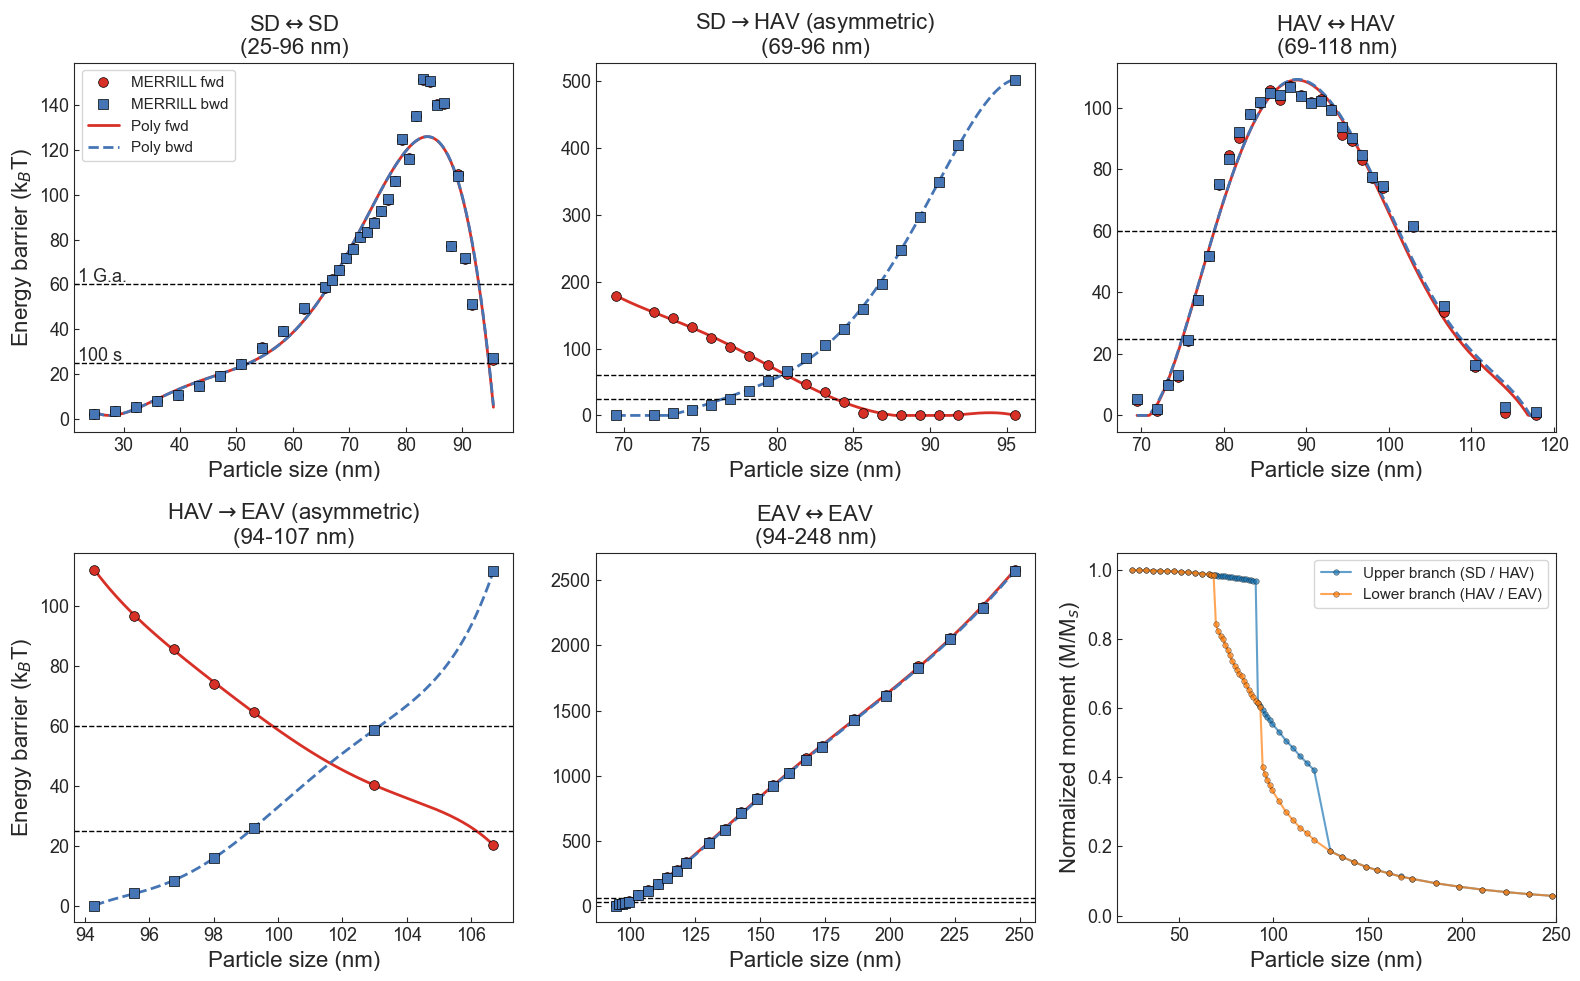

Saved d:\prebiotic_crm\plots_crm_efficiency_mc\figureS3.pdf


In [39]:
# -- Diagnostic: MERRILL knots (markers) vs polynomial fit (lines) -----------
mk_s, mk_fwd, mk_bwd = fine_grid['knots']['s'], fine_grid['knots']['fwd'], fine_grid['knots']['bwd']

poly_fwd, poly_bwd    = fine_grid['poly_fwd'], fine_grid['poly_bwd']
sl_upper_s, sl_upper_m = fine_grid['sl_upper_s'], fine_grid['sl_upper_m']
sl_lower_s, sl_lower_m = fine_grid['sl_lower_s'], fine_grid['sl_lower_m']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
col_fwd, col_bwd = '#d73027', '#4575b4'
mk_style = dict(markeredgecolor='k', markeredgewidth=0.5, zorder=5)

plot_cfg = [
    ('SD-SD',   r'SD$\leftrightarrow$SD'),
    ('SD-HAV',  r'SD$\rightarrow$HAV (asymmetric)'),
    ('HAV-HAV', r'HAV$\leftrightarrow$HAV'),
    ('HAV-EAV', r'HAV$\rightarrow$EAV (asymmetric)'),
    ('EAV-EAV', r'EAV$\leftrightarrow$EAV'),
]

for idx, (tr, title) in enumerate(plot_cfg):
    ax = axes[idx]
    if len(mk_s[tr]) == 0:
        ax.set_title(f'{title} (no data)', fontsize=10); continue
    ax.plot(crm.equiv_spherical_vol_diameter(mk_s[tr]), mk_fwd[tr] / kT, 'o', color=col_fwd, ms=7,
            label='MERRILL fwd', **mk_style)
    ax.plot(crm.equiv_spherical_vol_diameter(mk_s[tr]), mk_bwd[tr] / kT, 's', color=col_bwd, ms=7,
            label='MERRILL bwd', **mk_style)
    if tr in poly_fwd:
        s_fine = np.linspace(mk_s[tr][0], mk_s[tr][-1], 300)
        ax.plot(crm.equiv_spherical_vol_diameter(s_fine), np.maximum(poly_fwd[tr](s_fine), 0.0) / kT,
                '-', color=col_fwd, lw=2, label='Poly fwd')
        ax.plot(crm.equiv_spherical_vol_diameter(s_fine), np.maximum(poly_bwd[tr](s_fine), 0.0) / kT,
                '--', color=col_bwd, lw=2, label='Poly bwd')
    ax.set_xlabel('Particle size (nm)')
    if idx==0 or idx==3:
        ax.set_ylabel(r'Energy barrier (k$_B$T)')
    rng = f'{crm.equiv_spherical_vol_diameter(mk_s[tr][0]):.0f}-{crm.equiv_spherical_vol_diameter(mk_s[tr][-1]):.0f} nm'
    ax.set_title(f'{title}\n({rng})')
    if idx==0:
        ax.axhline(25, color='k', ls='--', lw=1, zorder=2)
        ax.axhline(60, color='k', ls='--', lw=1, zorder=2)
        ax.text(22, 26, '100 s')
        ax.text(22, 61, '1 G.a.')
        ax.legend()
    else:
        ax.axhline(25, color='k', ls='--', lw=1, zorder=2)
        ax.axhline(60, color='k', ls='--', lw=1, zorder=2)

# Panel 6: size-loop moment fractions
ax6 = axes[5]
ax6.plot(crm.equiv_spherical_vol_diameter(sl_upper_s), sl_upper_m, 'o-', mfc='tab:blue', ms=4, lw=1.5,
         mec='k', mew=0.3, alpha=0.7, label='Upper branch (SD / HAV)')
ax6.plot(crm.equiv_spherical_vol_diameter(sl_lower_s), sl_lower_m, 'o-', mfc='tab:orange', ms=4, lw=1.5,
         mec='k', mew=0.3, alpha=0.7, label='Lower branch (HAV / EAV)')
ax6.set_xlabel('Particle size (nm)')
ax6.set_ylabel(r'Normalized moment (M/M$_s$)')
# ax6.set_title('Size-loop moment fractions')
ax6.legend()
ax6.set_xlim(17, 250)
ax6.set_ylim(-0.02, 1.05)

plt.tight_layout()
savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_finegrid_diag.png')
fig.savefig(savepath, dpi=150, bbox_inches='tight')

savepath = os.path.join(PLOTS_DIR, 'figureS3.pdf')
fig.savefig(savepath, dpi=200, bbox_inches='tight')

plt.show(); plt.close(fig)
print(f'Saved {savepath}')


In [4]:
# -- Exact per-orientation Markov-chain final-state distributions ------------
b_hats_mc = crm._fibonacci_sphere(N_ORIENT_MC)

t0 = time.time()
p_per_orient = []
states_final = None
for b_hat in b_hats_mc:
    B_vec = B_MAG * b_hat
    states, p = crm.run_single_orientation_final_probs(B_vec, FINE_SIZES, GROWTH_TIME_MC, fine_all_barriers)
    if states_final is None:
        states_final = states
    assert states == states_final, 'state space differs between orientations -- unexpected'
    p_per_orient.append(p)
P_ORIENT = np.array(p_per_orient)   # (N_ORIENT_MC, n_states)

print(f'{N_ORIENT_MC} orientations computed in {time.time() - t0:.1f}s '
      f'(fine grid, {len(FINE_SIZES)} steps/call)')
print(f'Final state space ({len(states_final)} states): {states_final}')


5000 orientations computed in 1782.7s (fine grid, 181 steps/call)
Final state space (8 states): [('EAV', 0), ('EAV', 1), ('EAV', 2), ('EAV', 3), ('EAV', 4), ('EAV', 5), ('EAV', 6), ('EAV', 7)]


## 2. Markov-chain grain pool

A pool of `N_POOL` grains is built by assigning each grain a random
orientation index (`n_pool`, drawn from the `N_ORIENT_MC` computed
orientations), gathering that orientation's own exact final-state
probability row, and drawing one actual state per grain from it
(`crm.sample_from_probabilities`).

In [5]:
# -- Markov-chain grain pool ---------------------------------------------------
N_POOL = 200_000
rng_pool = np.random.default_rng(2026)

V_final = crm.grain_volume(SIZES[-1])
m_per_state   = np.array([np.linalg.norm(crm._moment(s, V_final, SIZES[-1]))
                           for s in states_final])
d_dot_b_final = np.array([[np.dot(b_hat, crm._direction(s)) for s in states_final]
                           for b_hat in b_hats_mc])   # (N_ORIENT_MC, n_states)

n_pool    = rng_pool.integers(0, N_ORIENT_MC, size=N_POOL)
P_pool    = P_ORIENT[n_pool]                                   # (N_POOL, n_states)
k_sampled = crm.sample_from_probabilities(P_pool, rng_pool)    # (N_POOL,)

cos_mc = d_dot_b_final[n_pool, k_sampled]
m_mc   = m_per_state[k_sampled]
M_par_mc, M_perp_mc = crm.moment_components(m_mc, cos_mc)

print(f'MC pool ({label_mc}, B={B_MAG*1e6:.0f} µT):  '
      f'<M_par>={M_par_mc.mean():.3e}  std={M_par_mc.std():.3e}  '
      f'(states used: {sorted(set(k_sampled.tolist()))})')


MC pool (1 day, B=30 µT):  <M_par>=3.426e-17  std=1.236e-16  (states used: [0, 1, 2, 3, 4, 5, 6, 7])


In [6]:
# -- Recompute the Boltzmann/cascade heuristic pools (crm_efficiency_final.ipynb) --
GROWTH_TIMES = {'1 hour': 3_600.0, '1 day': 86_400.0, '1 week': 604_800.0, '1 month': 2.592e6}
blocking, xi_table = crm.compute_blocking(GROWTH_TIMES, all_barriers, B_mag=B_MAG)

N_ORIENT_H = 20_000
b_hats_h, d_dot_b_h, adjacency_h = crm.orientation_dot_products(N_ORIENT_H)
SD_TO_HAV_h, HAV_TO_EAV_h = adjacency_h['SD_TO_HAV'], adjacency_h['HAV_TO_EAV']

rng_h    = np.random.default_rng(42)
n_pool_h = rng_h.integers(0, N_ORIENT_H, size=N_POOL)

xt_h    = xi_table[label_mc]
xi_SD_h, xi_HAV_h, xi_EAV_h = xt_h['SD']['xi'], xt_h['HAV']['xi'], xt_h['EAV']['xi']
# Report the moment at the grain's true FINAL volume (250 nm), not the blocking-size
# volume xi_table uses -- growth continues after the direction locks in, so the
# reported moment should reflect the grain's actual final size, matching the exact
# Markov-chain model's convention. The alignment probability (xi_EAV_h above) still
# correctly uses the blocking-size physics, since that's what governs the direction.
m_EAV_h = crm.HYST_FRACS[SIZES[-1]]['EAV'] * MS * V_final

k1_h, _     = crm.sample_direct_state(xi_SD_h,  d_dot_b_h['SD'][n_pool_h],  rng_h)
_, cos_ed_h = crm.sample_direct_state(xi_EAV_h, d_dot_b_h['EAV'][n_pool_h], rng_h)
k2_h, _     = crm.sample_cascade_step(k1_h, SD_TO_HAV_h, xi_HAV_h,
                                       d_dot_b_h['HAV'][n_pool_h], rng_h)
_, cos_ec_h = crm.sample_cascade_step(k2_h, HAV_TO_EAV_h, xi_EAV_h,
                                       d_dot_b_h['EAV'][n_pool_h], rng_h)

M_par_ed, M_perp_ed = crm.moment_components(m_EAV_h, cos_ed_h)
M_par_ec, M_perp_ec = crm.moment_components(m_EAV_h, cos_ec_h)

print(f'EAV direct   <M_par>={M_par_ed.mean():.3e}  std={M_par_ed.std():.3e}')
print(f'EAV cascade  <M_par>={M_par_ec.mean():.3e}  std={M_par_ec.std():.3e}')
print(f'MC (exact)   <M_par>={M_par_mc.mean():.3e}  std={M_par_mc.std():.3e}')


EAV direct   <M_par>=4.786e-17  std=1.211e-16
EAV cascade  <M_par>=5.905e-17  std=1.181e-16
MC (exact)   <M_par>=3.426e-17  std=1.236e-16


In [7]:
# -- Misfit vs N: exact Markov chain vs EAV direct vs EAV cascade -------------
N_MAX_MISFIT_MC = 30_000
N_SIZES_MC = sorted(set(max(1, int(round(x)))
                     for x in np.logspace(0, np.log10(N_MAX_MISFIT_MC), 50)))
K_TRIALS_MC = 20000
# K_TRIALS_MC = 500
rng_cmp = np.random.default_rng(99)

M_par_sum, Mx, My = crm.sample_assemblage_moments(M_par_mc, M_perp_mc, N_SIZES_MC, K_TRIALS_MC, rng_cmp)
misfit_arr_mc = crm.angular_misfit(M_par_sum, Mx, My)
misfit_mc     = misfit_arr_mc.mean(axis=1)
misfit_mc_std = misfit_arr_mc.std(axis=1)

M_par_sum, Mx, My = crm.sample_assemblage_moments(M_par_ed, M_perp_ed, N_SIZES_MC, K_TRIALS_MC, rng_cmp)
misfit_arr_ed = crm.angular_misfit(M_par_sum, Mx, My)
misfit_ed     = misfit_arr_ed.mean(axis=1)
misfit_ed_std = misfit_arr_ed.std(axis=1)

M_par_sum, Mx, My = crm.sample_assemblage_moments(M_par_ec, M_perp_ec, N_SIZES_MC, K_TRIALS_MC, rng_cmp)
misfit_arr_ec = crm.angular_misfit(M_par_sum, Mx, My)
misfit_ec     = misfit_arr_ec.mean(axis=1)
misfit_ec_std = misfit_arr_ec.std(axis=1)



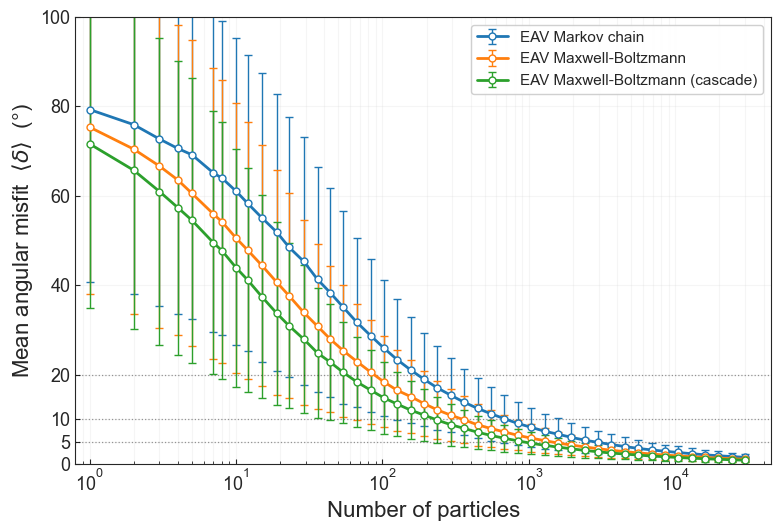

Saved d:\prebiotic_crm\plots_crm_efficiency_mc\crm_eff_mc_misfit_vs_N_comparison.png


In [ ]:
N_arr_mc = np.array(N_SIZES_MC, dtype=float)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(N_arr_mc, misfit_mc, yerr=misfit_mc_std, fmt='o-', color='tab:blue', mfc='w',
            ecolor='tab:blue', lw=2.0, ms=5, capsize=3, elinewidth=1.0, label='EAV Markov chain')
ax.errorbar(N_arr_mc, misfit_ed, yerr=misfit_ed_std, fmt='o-', color='tab:orange', mfc='w',
            ecolor='tab:orange', lw=2.0, ms=5, capsize=3, elinewidth=1.0, label='EAV Maxwell-Boltzmann')
ax.errorbar(N_arr_mc, misfit_ec, yerr=misfit_ec_std, fmt='o-', color='tab:green', mfc='w',
            ecolor='tab:green', lw=2.0, ms=5, capsize=3, elinewidth=1.0, label='EAV Maxwell-Boltzmann (cascade)')
for y_ref in [5, 10, 20]:
    ax.axhline(y_ref, color='k', ls=':', lw=0.9, alpha=0.4)
ax.set_xscale('log')
ax.set_xlim(0.8, N_MAX_MISFIT_MC * 1.5)
ax.set_ylim(0, 100)
ax.set_xlabel('Number of particles')
ax.set_ylabel(r'Mean angular misfit  $\langle\delta\rangle$  (°)')
ax.set_yticks([0,5,10,20,40,60,80,100],[0,5,10,20,40,60,80,100])
ax.legend(loc='upper right', framealpha=0.92)
ax.grid(True, which='both', alpha=0.18)
plt.tight_layout()
savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_misfit_vs_N_comparison.png')
fig.savefig(savepath, dpi=150, bbox_inches='tight')

savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_misfit_vs_N_comparison.png')
fig.savefig(savepath, dpi=150, bbox_inches='tight')

plt.show(); plt.close(fig)
print(f'Saved {savepath}')

## 4. Critical assemblage size vs field: exact vs heuristic

In [9]:
# -- Exact Markov-chain grain pools at each field value (expensive) ----------
B_SWEEP_CRIT  = np.logspace(np.log10(0.1), np.log10(150), 15) * 1e-6   # 0.5-200 uT, matches crm_efficiency_final.ipynb's B_SWEEP_C
N_ORIENT_CRIT = 1000

rng_crit = np.random.default_rng(31415)
mc_pools_by_B = {}   # B -> (M_par, M_perp) pool arrays
eff_mc_by_B   = {}   # B -> exact (no-sampling) mean grain efficiency <mu_par>/m

t0 = time.time()
for B in B_SWEEP_CRIT:
    b_hats_crit = crm._fibonacci_sphere(N_ORIENT_CRIT)

    p_list = []
    states_b = None
    for b_hat in b_hats_crit:
        B_vec = B * b_hat
        states, p = crm.run_single_orientation_final_probs(B_vec, FINE_SIZES, GROWTH_TIME_MC, fine_all_barriers)
        if states_b is None:
            states_b = states
        p_list.append(p)
    P_orient_b = np.array(p_list)

    m_per_state_b = np.array([np.linalg.norm(crm._moment(s, V_final, SIZES[-1])) for s in states_b])
    d_dot_b_b     = np.array([[np.dot(bh, crm._direction(s)) for s in states_b]
                               for bh in b_hats_crit])

    n_pool_crit = rng_crit.integers(0, N_ORIENT_CRIT, size=N_POOL)
    P_pool_b    = P_orient_b[n_pool_crit]
    k_b         = crm.sample_from_probabilities(P_pool_b, rng_crit)
    cos_b       = d_dot_b_b[n_pool_crit, k_b]
    m_b         = m_per_state_b[k_b]
    M_par_b, M_perp_b = crm.moment_components(m_b, cos_b)
    mc_pools_by_B[B] = (M_par_b, M_perp_b)

    # Exact (deterministic) population-average efficiency -- no sampling noise,
    # since all EAV states share the same moment magnitude at this final size.
    eff_mc_by_B[B] = float((P_orient_b * d_dot_b_b).sum(axis=1).mean())

print(f'Computed MC pools at {len(B_SWEEP_CRIT)} field values in {time.time() - t0:.1f}s')


Computed MC pools at 15 field values in 4904.2s


In [10]:
# -- Critical N vs B: exact MC vs EAV direct/cascade heuristic ---------------
N_GRID_CRIT   = sorted(set(max(1, int(round(x))) for x in np.logspace(0, 4, 16)))
K_TRIALS_CRIT = 1000
THRESHOLD     = 10.0

# let weak-field curves escalate past N_GRID_CRIT, up to this cap
# (K_trials tapers down automatically at large N -- see
# crm.critical_N's docstring; still no CLT at any N)

N_EXTEND_MAX  = 100_000_000                                   

rng_res = np.random.default_rng(2027)

N_p95_mc, N_mean_mc = [], []
for B in B_SWEEP_CRIT:
    Mp, Mo = mc_pools_by_B[B]
    p95, mean = crm.critical_N(Mp, Mo, N_GRID_CRIT, K_TRIALS_CRIT, rng_res, threshold_deg=THRESHOLD,
                                extend=True, extend_max_N=N_EXTEND_MAX)
    N_p95_mc.append(p95); N_mean_mc.append(mean)

xt_crit = xi_table[label_mc]
xi_SD_c, xi_HAV_c, xi_EAV_c = xt_crit['SD']['xi'], xt_crit['HAV']['xi'], xt_crit['EAV']['xi']
m_EAV_c = crm.HYST_FRACS[SIZES[-1]]['EAV'] * MS * V_final   # final-size volume, see S3 above

N_p95_ed, N_mean_ed, N_p95_ec, N_mean_ec = [], [], [], []
heuristic_pools_by_B = {}   # B -> (M_par, M_perp) EAV cascade pool, for later reuse
eff_cascade_by_B     = {}   # B -> exact (no-sampling) EAV cascade efficiency
for B in B_SWEEP_CRIT:
    scale = B / B_MAG
    _, cos_ed_c = crm.sample_direct_state(xi_EAV_c * scale, d_dot_b_h['EAV'][n_pool_h], rng_res)
    k1_c, _     = crm.sample_direct_state(xi_SD_c  * scale, d_dot_b_h['SD'][n_pool_h],  rng_res)
    k2_c, _     = crm.sample_cascade_step(k1_c, SD_TO_HAV_h, xi_HAV_c * scale,
                                           d_dot_b_h['HAV'][n_pool_h], rng_res)
    _, cos_ec_c = crm.sample_cascade_step(k2_c, HAV_TO_EAV_h, xi_EAV_c * scale,
                                           d_dot_b_h['EAV'][n_pool_h], rng_res)

    Mp_ed, Mo_ed = crm.moment_components(m_EAV_c, cos_ed_c)
    Mp_ec, Mo_ec = crm.moment_components(m_EAV_c, cos_ec_c)

    p95, mean = crm.critical_N(Mp_ed, Mo_ed, N_GRID_CRIT, K_TRIALS_CRIT, rng_res, threshold_deg=THRESHOLD,
                                extend=True, extend_max_N=N_EXTEND_MAX)
    N_p95_ed.append(p95); N_mean_ed.append(mean)
    p95, mean = crm.critical_N(Mp_ec, Mo_ec, N_GRID_CRIT, K_TRIALS_CRIT, rng_res, threshold_deg=THRESHOLD,
                                extend=True, extend_max_N=N_EXTEND_MAX)
    N_p95_ec.append(p95); N_mean_ec.append(mean)
    heuristic_pools_by_B[B] = (Mp_ec, Mo_ec)

    # Exact (deterministic) EAV cascade efficiency at this field -- no sampling noise
    p_sd_exact  = crm.boltzmann_p(xi_SD_c * scale, d_dot_b_h['SD'])
    p_hav_exact = crm.boltzmann_cascade_step(p_sd_exact, SD_TO_HAV_h, xi_HAV_c * scale,
                                              d_dot_b_h['HAV'])
    p_eav_exact = crm.boltzmann_cascade_step(p_hav_exact, HAV_TO_EAV_h, xi_EAV_c * scale,
                                              d_dot_b_h['EAV'])
    eff_cascade_by_B[B] = crm.boltzmann_efficiency(p_eav_exact, d_dot_b_h['EAV'])

print('Critical-N-vs-B sweep complete.')


Critical-N-vs-B sweep complete.


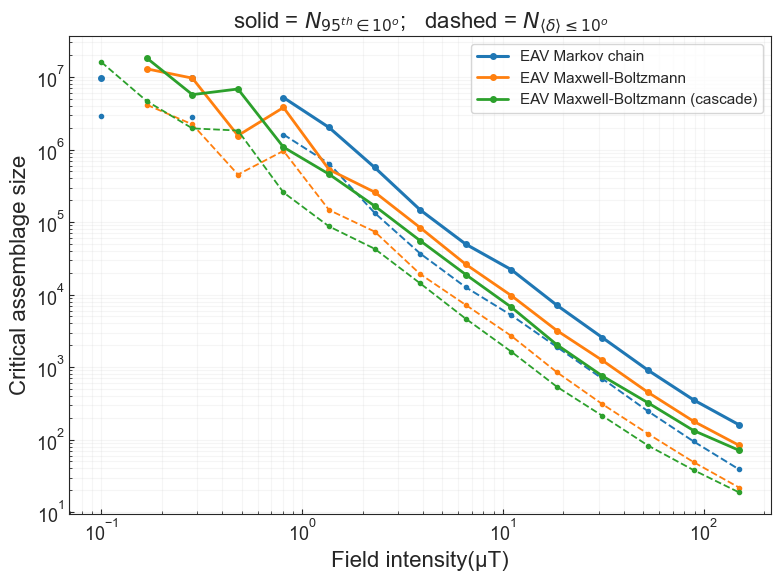

Saved d:\prebiotic_crm\plots_crm_efficiency_mc\crm_eff_mc_critical_N_vs_B.png


In [11]:
# -- Plot ----------------------------------------------------------------------
B_uT_crit = B_SWEEP_CRIT * 1e6

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(B_uT_crit, N_p95_mc,  color='tab:blue',       lw=2.2, ls='-',  marker='o', ms=4, label='EAV Markov chain')
ax.plot(B_uT_crit, N_mean_mc, color='tab:blue',       lw=1.4, ls='--', marker='o', ms=3)
ax.plot(B_uT_crit, N_p95_ed,  color='tab:orange', lw=2.0, ls='-',  marker='o', ms=4, label='EAV Maxwell-Boltzmann')
ax.plot(B_uT_crit, N_mean_ed, color='tab:orange', lw=1.3, ls='--', marker='o', ms=3)
ax.plot(B_uT_crit, N_p95_ec,  color='tab:green', lw=2.0, ls='-',  marker='o', ms=4, label='EAV Maxwell-Boltzmann (cascade)')
ax.plot(B_uT_crit, N_mean_ec, color='tab:green', lw=1.3, ls='--', marker='o', ms=3)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Field intensity(µT)')
ax.set_ylabel('Critical assemblage size')
ax.set_title(r'solid = $N_{95^{th} \in 10^o}$;   dashed = $N_{\langle\delta\rangle \leq 10^o}$')
ax.legend(loc='upper right')
ax.grid(True, which='both', alpha=0.18)
plt.tight_layout()
savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_critical_N_vs_B.png')
fig.savefig(savepath, dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)
print(f'Saved {savepath}')

## 5. Moment linearity vs field: exact vs heuristic


In [12]:
# -- Moment vs field for several N: EAV cascade (heuristic) vs exact MC ------
N_DISPLAY_CMP = [2, 5, 10, 100, 1_000, 10_000]   # matches crm_efficiency_final.ipynb's N_COMB_S
K_TRIALS_CMP  = 1000

rng_cmp2      = np.random.default_rng(555)

moment_cascade_by_N = {N: np.empty(len(B_SWEEP_CRIT)) for N in N_DISPLAY_CMP}
moment_mc_by_N      = {N: np.empty(len(B_SWEEP_CRIT)) for N in N_DISPLAY_CMP}

for bi, B in enumerate(B_SWEEP_CRIT):
    Mp_c, Mo_c = heuristic_pools_by_B[B]
    M_par_sum, Mx, My = crm.sample_assemblage_moments(Mp_c, Mo_c, N_DISPLAY_CMP, K_TRIALS_CMP, rng_cmp2)
    mag_c = crm.moment_magnitude(M_par_sum, Mx, My).mean(axis=1)

    Mp_m, Mo_m = mc_pools_by_B[B]
    M_par_sum, Mx, My = crm.sample_assemblage_moments(Mp_m, Mo_m, N_DISPLAY_CMP, K_TRIALS_CMP, rng_cmp2)
    mag_m = crm.moment_magnitude(M_par_sum, Mx, My).mean(axis=1)

    for Ni, N in enumerate(N_DISPLAY_CMP):
        moment_cascade_by_N[N][bi] = mag_c[Ni]
        moment_mc_by_N[N][bi]      = mag_m[Ni]

print('Moment-vs-field-vs-N sweep complete.')


Moment-vs-field-vs-N sweep complete.


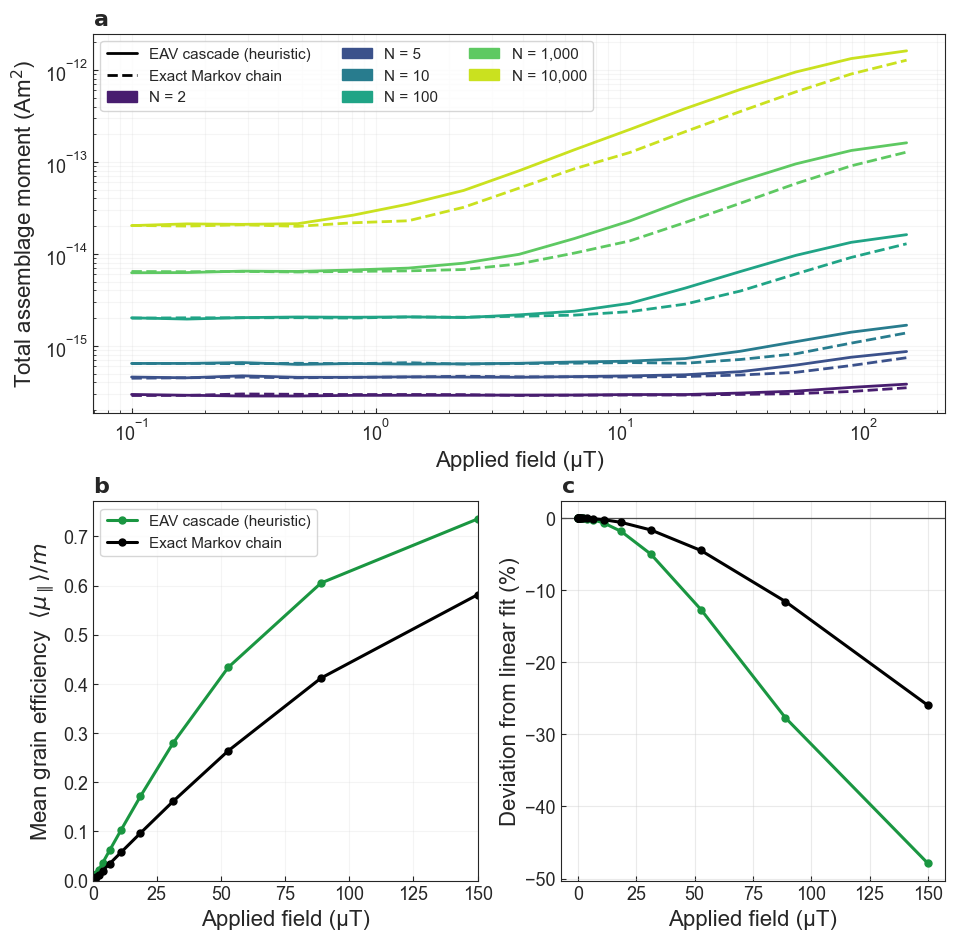

Saved d:\prebiotic_crm\plots_crm_efficiency_mc\crm_eff_mc_moment_linearity_comparison.png


In [13]:
# -- 3-panel figure: log moment-vs-N, linear efficiency, linear deviation ----
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

B_uT_crit  = B_SWEEP_CRIT * 1e6
COLS_N_CMP = [plt.cm.viridis(v) for v in np.linspace(0.08, 0.92, len(N_DISPLAY_CMP))]

fig = plt.figure(figsize=(11, 11))
gs = fig.add_gridspec(4, 4, hspace=0.6, wspace=0.55)
ax_top = fig.add_subplot(gs[0:2, 0:4])
ax_lin = fig.add_subplot(gs[2:4, 0:2])
ax_dev = fig.add_subplot(gs[2:4, 2:4])

# -- top: moment vs field, log-log, cascade (solid) vs exact MC (dashed) -----
for N, col in zip(N_DISPLAY_CMP, COLS_N_CMP):
    ax_top.plot(B_uT_crit, moment_cascade_by_N[N], color=col, lw=2.0, ls='-')
    ax_top.plot(B_uT_crit, moment_mc_by_N[N],      color=col, lw=2.0, ls='--')
ax_top.set_xscale('log'); ax_top.set_yscale('log')
ax_top.set_xlabel('Applied field (µT)')
ax_top.set_ylabel(r'Total assemblage moment (Am$^{2}$)')
ax_top.set_title(r'$\mathbf{a}$', loc='left')
leg_top = ([Line2D([0], [0], color='k', lw=2.0, ls='-',  label='EAV cascade (heuristic)'),
            Line2D([0], [0], color='k', lw=2.0, ls='--', label='Exact Markov chain')] +
           [Patch(color=col, label=f'N = {N:,}') for N, col in zip(N_DISPLAY_CMP, COLS_N_CMP)])
ax_top.legend(handles=leg_top, loc='upper left', ncols=3)
ax_top.grid(True, which='both', alpha=0.18)

# -- bottom-left: mean grain efficiency, linear scale ------------------------
eff_cascade_arr = np.array([eff_cascade_by_B[B] for B in B_SWEEP_CRIT])
eff_mc_arr      = np.array([eff_mc_by_B[B]      for B in B_SWEEP_CRIT])

ax_lin.plot(B_uT_crit, eff_cascade_arr, color='#1a9641', lw=2.2, marker='o', ms=5,
            label='EAV cascade (heuristic)')
ax_lin.plot(B_uT_crit, eff_mc_arr, color='k', lw=2.2, marker='o', ms=5,
            label='Exact Markov chain')
ax_lin.set_xlabel('Applied field (µT)')
ax_lin.set_ylabel(r'Mean grain efficiency  $\langle\mu_\parallel\rangle/m$')
ax_lin.set_title(r'$\mathbf{b}$', loc='left')
ax_lin.legend()
ax_lin.set_xlim(0, B_uT_crit[-1])
ax_lin.set_ylim(0)
ax_lin.grid(True, alpha=0.2)

# -- bottom-right: relative deviation from small-field linear reference ------
N_FIT_CMP = 5

def _deviation(eff_arr):
    k_fit = np.sum(B_uT_crit[:N_FIT_CMP] * eff_arr[:N_FIT_CMP]) / np.sum(B_uT_crit[:N_FIT_CMP] ** 2)
    ref = k_fit * B_uT_crit
    return (eff_arr - ref) / ref * 100.0

dev_cascade = _deviation(eff_cascade_arr)
dev_mc      = _deviation(eff_mc_arr)

ax_dev.axhline(0.0, color='0.3', lw=0.9)
ax_dev.plot(B_uT_crit, dev_cascade, color='#1a9641', lw=2.2, marker='o', ms=5,
            label='EAV cascade (heuristic)')
ax_dev.plot(B_uT_crit, dev_mc, color='k', lw=2.2, marker='o', ms=5,
            label='Exact Markov chain')
ax_dev.set_xlabel('Applied field (µT)')
ax_dev.set_ylabel('Deviation from linear fit (%)')
ax_dev.set_title(r'$\mathbf{c}$', loc='left')
ax_dev.grid(True, alpha=0.4)

# fig.suptitle(f'Moment linearity vs field: exact MC vs heuristic  |  {label_mc}', fontsize=13, y=1.0)
savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_moment_linearity_comparison.png')
fig.savefig(savepath, dpi=200, bbox_inches='tight')
plt.show(); plt.close(fig)
print(f'Saved {savepath}')


### 5b. Moment linearity vs field — exact Markov chain only

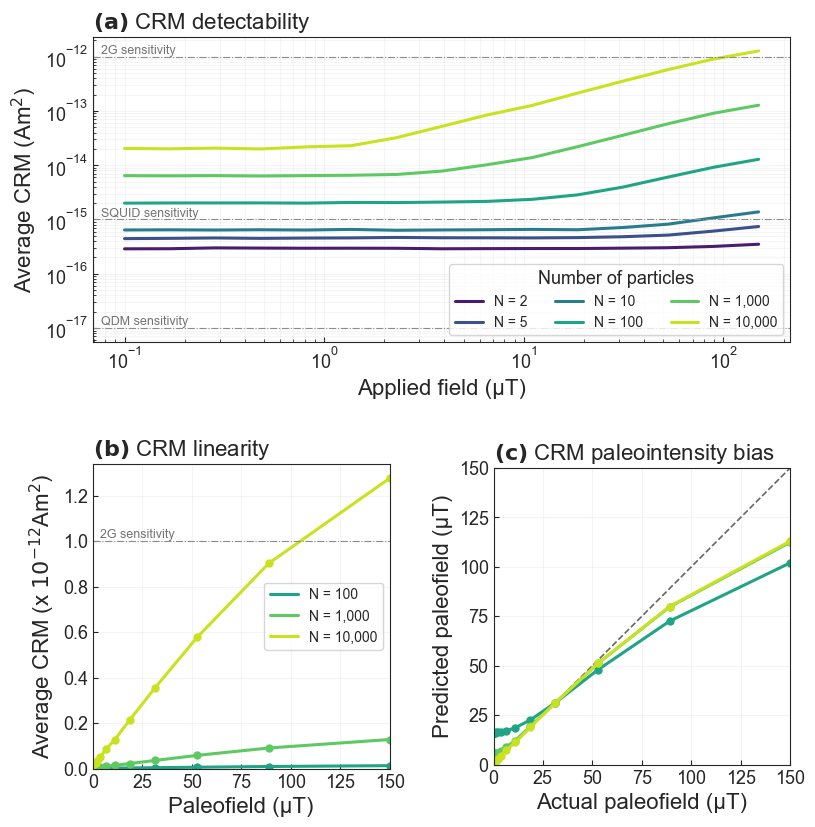

Saved d:\prebiotic_crm\plots_crm_efficiency_mc\figure3.pdf


In [40]:
# -- Moment linearity vs field: exact Markov chain only -----------------------
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(9, 9.5))
gs = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35, height_ratios=[1, 1])
ax_top = fig.add_subplot(gs[0, :])
ax_b   = fig.add_subplot(gs[1, 0])
ax_c   = fig.add_subplot(gs[1, 1])

# -- top: moment vs field, log-log, one solid line per N ---------------------
for N, col in zip(N_DISPLAY_CMP, COLS_N_CMP):
    ax_top.plot(B_uT_crit, moment_mc_by_N[N], color=col, lw=2.2, ls='-')
ax_top.set_xscale('log'); ax_top.set_yscale('log')
ax_top.set_xlabel('Applied field (µT)')
ax_top.set_ylabel(r'Average CRM (Am$^{2}$)')
ax_top.set_title(r"$\mathbf{(a)}$ CRM detectability", loc='left')

# Instrument sensitivity reference lines
for yval, sens_lbl in [(1e-12, '2G sensitivity'),
                       (1e-15, 'SQUID sensitivity'),
                       (1e-17, 'QDM sensitivity')]:
    ax_top.axhline(yval, color='0.55', lw=0.8, ls='-.')
    ax_top.text(0.07, yval, f'  {sens_lbl}', va='bottom', ha='left', color='0.45', fontsize=9)

leg_top_mc = [Line2D([0], [0], color=col, lw=2.2, label=f'N = {N:,}')
              for N, col in zip(N_DISPLAY_CMP, COLS_N_CMP)]
ax_top.legend(title='Number of particles', handles=leg_top_mc, loc='lower right', fontsize=10, ncols=3)
ax_top.grid(True, which='both', alpha=0.18)

# -- bottom-left (b): total assemblage moment vs field, linear scale --------
N_BC   = [100, 1_000, 10_000]
idx_BC = [N_DISPLAY_CMP.index(N) for N in N_BC]   # reuse panel (a)'s own color assignment

for N, ci in zip(N_BC, idx_BC):
    ax_b.plot(B_uT_crit, moment_mc_by_N[N]*1e12, color=COLS_N_CMP[ci], lw=2.2, marker='o', ms=5)

ax_b.axhline(y=1, lw=0.8, ls='-.', color='0.55')
ax_b.text(0.07, 1, '  2G sensitivity', va='bottom', ha='left', color='0.45', fontsize=9)

ax_b.set_xlabel('Paleofield (µT)')
ax_b.set_ylabel(r'Average CRM (x $10^{-12}$Am$^{2}$)')
ax_b.set_title(r'$\mathbf{(b)}$ CRM linearity', loc='left')
ax_b.set_xlim(0, B_uT_crit[-1])
ax_b.set_ylim(0)
ax_b.grid(True, alpha=0.2)

leg_b_mc = [Line2D([0], [0], color=col, lw=2.2, label=f'N = {N:,}')
              for N, col in zip(N_DISPLAY_CMP[3:], COLS_N_CMP[3:])]
ax_b.legend(handles=leg_b_mc, loc='center right', fontsize=10, ncols=1)

# -- bottom-right (c): predicted (inferred) vs actual paleofield ------------
# Calibrate a single-point slope k_fit per N from the standard B_MAG (30 uT)
# reference field, Thellier-style (one known lab field), rather than fitting
# a low-field slope. The lowest fields on this sweep sit in a noise floor
# where the sampled assemblage moment magnitude is dominated by the
# perpendicular (randomly-summed) components rather than the shrinking
# parallel/CRM signal, so a through-origin fit to those points wildly
# overestimates the slope and biases every predicted field low. B_MAG is
# comfortably past that regime.
i_ref = int(np.argmin(np.abs(B_uT_crit - B_MAG * 1e6)))

def _predicted_paleofield(N):
    m = moment_mc_by_N[N]
    k_fit = m[i_ref] / B_uT_crit[i_ref]
    return m / k_fit

B_ref = np.array([0.0, B_uT_crit[-1]])
ax_c.plot(B_ref, B_ref, color='0.4', lw=1.2, ls='--', zorder=1, label='1:1 (perfect recovery)')
for N, ci in zip(N_BC, idx_BC):
    ax_c.plot(B_uT_crit, _predicted_paleofield(N), color=COLS_N_CMP[ci], lw=2.2, marker='o', ms=5)
ax_c.set_xlabel('Actual paleofield (µT)')
ax_c.set_ylabel('Predicted paleofield (µT)')
ax_c.set_title(r'$\mathbf{(c)}$ CRM paleointensity bias', loc='left')
ax_c.set_xlim(0, B_uT_crit[-1]); ax_c.set_ylim(0, B_uT_crit[-1])

ax_b.set_xticks([0,25,50,75,100,125,150], [0,25,50,75,100,125,150])
ax_c.set_xticks([0,25,50,75,100,125,150], [0,25,50,75,100,125,150])
ax_c.set_yticks([0,25,50,75,100,125,150], [0,25,50,75,100,125,150])

ax_c.set_aspect('equal', adjustable='box')
# ax_c.legend(fontsize=9, loc='upper left')
ax_c.grid(True, alpha=0.2)

savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_moment_linearity_mc_only.png')
fig.savefig(savepath, dpi=200, bbox_inches='tight')

savepath = os.path.join(PLOTS_DIR, 'figure3.pdf')
fig.savefig(savepath, dpi=300, bbox_inches='tight')

plt.show(); plt.close(fig)
print(f'Saved {savepath}')


## 6. Combined summary figure (exact Markov chain)

In [15]:
# -- MC pools at literal fixed fields shared by panels (a-c)/(d) and the -----
# -- stereonet-grid rows (fresh integration, not on the B_SWEEP_CRIT grid) --
# Matches crm_efficiency_final.ipynb's literal field choices exactly: B = 1, 5
# uT (panels a-b), 0.5/1/2/5/10/50 uT (panel d, + 30 uT reused from the S2
# reference pool), and 1/5/10 uT (stereonet-grid rows, + 30 uT reused).
B_EXTRA = np.array([0.5, 1, 2, 5, 10, 50]) * 1e-6
B_HALF, B_1, B_2, B_5, B_10, B_50 = B_EXTRA

rng_extra = np.random.default_rng(7071)
mc_pools_extra = {}   # B -> (M_par, M_perp) pool arrays, keyed by B_EXTRA values

t0 = time.time()
for B in B_EXTRA:
    b_hats_ex = crm._fibonacci_sphere(N_ORIENT_CRIT)

    p_list = []
    states_ex = None
    for b_hat in b_hats_ex:
        B_vec = B * b_hat
        states, p = crm.run_single_orientation_final_probs(B_vec, FINE_SIZES, GROWTH_TIME_MC, fine_all_barriers)
        if states_ex is None:
            states_ex = states
        p_list.append(p)
    P_orient_ex = np.array(p_list)

    m_per_state_ex = np.array([np.linalg.norm(crm._moment(s, V_final, SIZES[-1])) for s in states_ex])
    d_dot_b_ex     = np.array([[np.dot(bh, crm._direction(s)) for s in states_ex]
                                for bh in b_hats_ex])

    n_pool_ex = rng_extra.integers(0, N_ORIENT_CRIT, size=N_POOL)
    P_pool_ex = P_orient_ex[n_pool_ex]
    k_ex      = crm.sample_from_probabilities(P_pool_ex, rng_extra)
    cos_ex    = d_dot_b_ex[n_pool_ex, k_ex]
    m_ex      = m_per_state_ex[k_ex]
    M_par_ex, M_perp_ex = crm.moment_components(m_ex, cos_ex)
    mc_pools_extra[B] = (M_par_ex, M_perp_ex)

def _pool_lookup(B):
    """(M_par, M_perp) pool for a literal field value: the S2 reference pool
    at B_MAG, or the dedicated B_EXTRA pool otherwise."""
    return (M_par_mc, M_perp_mc) if B == B_MAG else mc_pools_extra[B]

print(f'Computed MC pools at {len(B_EXTRA)} extra field values in {time.time() - t0:.1f}s')


Computed MC pools at 6 extra field values in 1833.8s


##### 10 degrees error

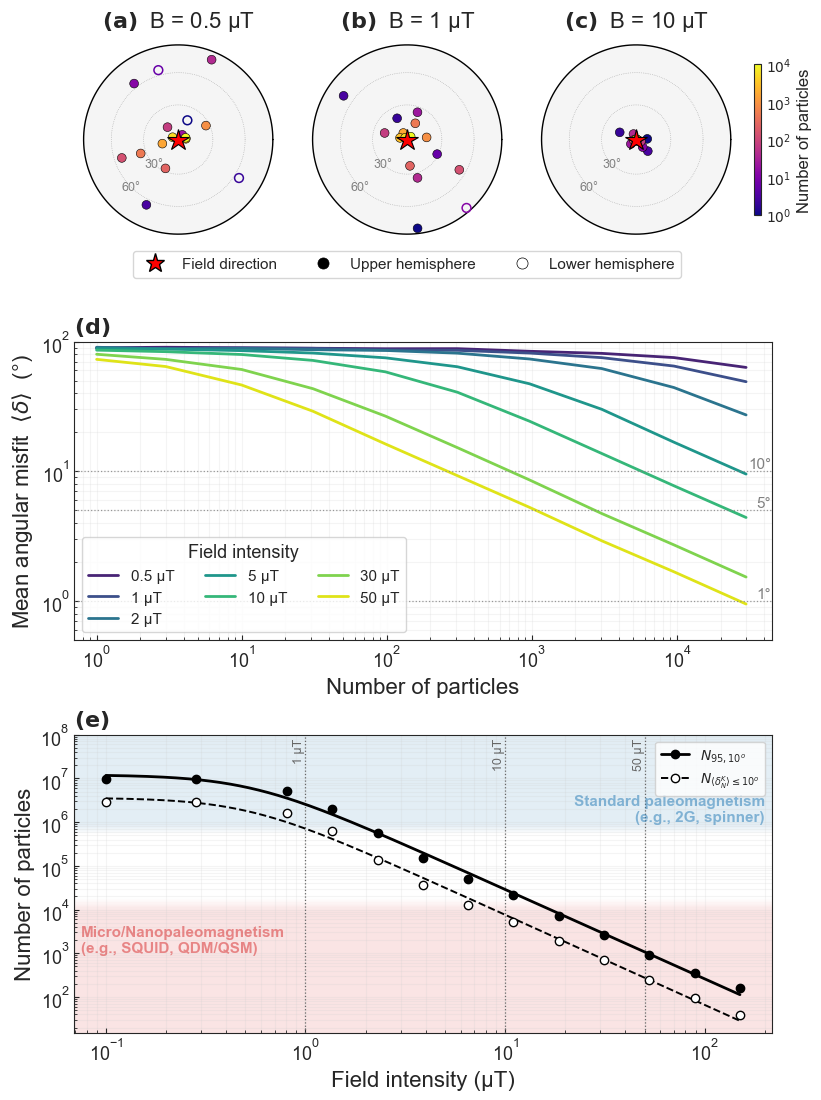

Saved d:\prebiotic_crm\plots_crm_efficiency_mc\figure2.pdf


In [43]:
# -- Combined summary figure: stereonets + misfit-vs-N + critical-N-vs-B -----
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.lines import Line2D

def _draw_net(ax, R=np.sqrt(2)):
    th = np.linspace(0, 2 * np.pi, 300)
    ax.fill(R * np.cos(th), R * np.sin(th), color='#f5f5f5', zorder=0)
    ax.plot(R * np.cos(th), R * np.sin(th), 'k-', lw=1.0, zorder=1)
    for deg in [30, 60]:
        r_ref = 2.0 * np.sin(np.radians(deg / 2.0))
        ax.plot(r_ref * np.cos(th), r_ref * np.sin(th), 'k:', lw=0.5, alpha=0.3, zorder=2)
        ax.text(r_ref*np.cos(np.radians(225)), r_ref*np.sin(np.radians(225)),
                        f'{deg}°', ha='center', va='center', color='0.5', zorder=3, fontsize=9)        
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_xlim(-R * 1.1, R * 1.1); ax.set_ylim(-R * 1.1, R * 1.1)

# -- (a-c) Mean-vector stereonets over continuous N ---------------------------
N_MEAN_MC = sorted(set(max(1, int(round(x))) for x in np.logspace(0, 4, 16)))
K_MEAN_MC = 1000

rng_comb  = np.random.default_rng(9001)
b_hat_lab = crm._n([-1., -1., -1.])
e1, e2    = crm.lab_frame_basis(b_hat_lab)
norm_N    = mcolors.LogNorm(vmin=N_MEAN_MC[0], vmax=N_MEAN_MC[-1])
cmap_N    = plt.cm.plasma

stereo_sources = [
    (0.5, _pool_lookup(B_HALF)),
    (1.0, _pool_lookup(B_1)),
    (10.0, _pool_lookup(B_10)),
]
stereo_labels = [r'$\mathbf{(a)}$  B = %.1f µT' % stereo_sources[0][0],
                 r'$\mathbf{(b)}$  B = %.0f µT' % stereo_sources[1][0],
                 r'$\mathbf{(c)}$  B = %.0f µT' % stereo_sources[2][0]]

fig = plt.figure(figsize=(9, 13))
gs     = GridSpec(3, 1, figure=fig, height_ratios=[0.72, 1, 1], hspace=0.35)
gs_top = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[0], wspace=0.10)
ax_sn  = [fig.add_subplot(gs_top[0, c]) for c in range(3)]
ax_d   = fig.add_subplot(gs[1])
ax_e   = fig.add_subplot(gs[2])

for ax, (B_val, pool), lbl in zip(ax_sn, stereo_sources, stereo_labels):
    Mp, Mo = pool
    M_par_sum, Mx, My = crm.sample_assemblage_moments(Mp, Mo, N_MEAN_MC, K_MEAN_MC, rng_comb)

    mean_x, mean_y, upper_mask = [], [], []
    for i in range(len(N_MEAN_MC)):
        M3d = (M_par_sum[i][:, None] * b_hat_lab
               + Mx[i][:, None] * e1 + My[i][:, None] * e2)
        # Mean vector: average the raw (un-normalized) per-realization moment
        # vectors first, then normalize once -- this is the net remanence
        # direction a magnetometer would actually record. NOT a Fisher mean
        # (which would normalize each realization to a unit vector before
        # averaging, discarding magnitude information).
        mean_M3d = M3d.mean(axis=0)
        mean_dir = mean_M3d / np.linalg.norm(mean_M3d)
        xp, yp, up = crm.ea_project(mean_dir.reshape(1, 3), b_hat_lab, e1, e2)
        mean_x.append(float(xp[0])); mean_y.append(float(yp[0])); upper_mask.append(bool(up[0]))
    mean_x, mean_y = np.array(mean_x), np.array(mean_y)
    upper_mask = np.array(upper_mask, dtype=bool)

    _draw_net(ax)
    ax.plot(0, 0, '*', ms=16, color='r', markeredgecolor='k', markeredgewidth=0.8, zorder=10)
    cols = np.array([cmap_N(norm_N(N)) for N in N_MEAN_MC])
    ax.scatter(mean_x[upper_mask], mean_y[upper_mask], color=cols[upper_mask],
               s=40, edgecolors='k', linewidths=0.4, zorder=8)
    ax.scatter(mean_x[~upper_mask], mean_y[~upper_mask], facecolors='none',
               edgecolors=cols[~upper_mask], s=40, linewidths=1.1, zorder=8)
    ax.set_title(lbl)

sm = plt.cm.ScalarMappable(cmap=cmap_N, norm=norm_N)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_sn, orientation='vertical',
                     fraction=0.025, pad=0.02, shrink=0.7, aspect=22)
cbar.set_label('Number of particles', fontsize=12)
cbar.set_ticks([1, 10, 100, 1_000, 10_000])
cbar.set_ticklabels([r'$10^0$', r'$10^1$', r'$10^2$', r'$10^3$', r'$10^4$'], fontsize=10)

leg_handles = [Line2D([0], [0], marker='*', color='w', markerfacecolor='r',
                      markeredgecolor='k', markersize=14, label='Field direction'),
               Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
                      markeredgecolor='k', markeredgewidth=0.5, markersize=8,
                      label='Upper hemisphere'),
               Line2D([0], [0], marker='o', color='w', markerfacecolor='w',
                      markeredgecolor='k', markeredgewidth=0.5, markersize=8,
                      label='Lower hemisphere')]
ax_sn[1].legend(handles=leg_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.2))

# -- (d) Mean angular misfit vs N, dedicated field grid ------------------------
N_SIZES_D  = sorted(set(max(1, int(round(x))) for x in np.logspace(0, np.log10(30_000), 10)))
K_TRIALS_D = 4000

B_FIELDS_D = [B_HALF, B_1, B_2, B_5, B_10, B_MAG, B_50]   # 0.5,1,2,5,10,30,50 uT -- matches crm_efficiency_final.ipynb's B_FIELDS_D
COLS_B_D   = plt.cm.viridis(np.linspace(0.1, 0.95, len(B_FIELDS_D)))

for B, col in zip(B_FIELDS_D, COLS_B_D):
    Mp, Mo = _pool_lookup(B)
    M_par_sum, Mx, My = crm.sample_assemblage_moments(Mp, Mo, N_SIZES_D, K_TRIALS_D, rng_comb)
    misfit_d = crm.angular_misfit(M_par_sum, Mx, My).mean(axis=1)
    ax_d.plot(N_SIZES_D, misfit_d, color=col, lw=2.0, label=f'{B * 1e6:g} µT')
for y_ref in [10, 5, 1]:
    ax_d.axhline(y_ref, color='0.5', ls=':', lw=0.9, alpha=0.8)
    ax_d.text(N_SIZES_D[-1] * 1.49, y_ref * 1.05, f'{y_ref}°', color='0.5', fontsize=11, ha='right')
ax_d.set_xscale('log'); ax_d.set_yscale('log')
ax_d.set_xlim(N_SIZES_D[0] * 0.7, N_SIZES_D[-1] * 1.5)
ax_d.set_ylim(0.5, 100)
ax_d.set_xlabel('Number of particles')
ax_d.set_ylabel(r'Mean angular misfit  $\langle\delta\rangle$  (°)')
ax_d.set_title(r'$\mathbf{(d)}$', loc='left')
ax_d.legend(title='Field intensity', loc='lower left', ncol=3)
ax_d.grid(True, which='both', alpha=0.2)

# -- (e) Critical assemblage size vs field, points + log-log best-fit line ---
def _broken_powerlaw_fit(B_arr, N_list, n_dense=200):
    """Smoothly-broken power-law fit: N(B) = N0 / (1 + (B/Bc)**alpha) --
    a low-field plateau (N -> N0 as B -> 0) rolling over into a power-law
    decay (N ~ N0*(Bc/B)**alpha) above the break field Bc. Fit by nonlinear
    least squares on log10(N) vs log10(B), skipping any None entries (fields
    where critical_N found no crossing within its search range). Returns
    (B_fit, N_fit) -- a dense grid spanning the plotted field range -- or
    None if <2 valid points or the fit fails to converge."""
    from scipy.optimize import curve_fit

    B_arr = np.asarray(B_arr, dtype=float)
    mask = np.array([v is not None for v in N_list])
    if mask.sum() < 2:
        return None
    B_obs = B_arr[mask]
    N_obs = np.array([N_list[i] for i in range(len(N_list)) if mask[i]], dtype=float)
    logB, logN = np.log10(B_obs), np.log10(N_obs)

    def _model_log(logB, log_N0, log_Bc, alpha):
        return log_N0 - np.log10(1.0 + (10 ** (logB - log_Bc)) ** alpha)

    slope0 = (logN[-1] - logN[0]) / (logB[-1] - logB[0]) if logB[-1] != logB[0] else -1.0
    p0 = [logN.max(), np.median(logB), max(0.5, -slope0)]
    try:
        popt, _ = curve_fit(_model_log, logB, logN, p0=p0, maxfev=20000)
    except RuntimeError:
        return None
    B_fit = np.logspace(np.log10(B_arr.min()), np.log10(B_arr.max()), n_dense)
    N_fit = 10 ** _model_log(np.log10(B_fit), *popt)
    return B_fit, N_fit

# Points only (no connecting line) -- filled = P95, open = mean, matching
# the filled/open = upper/lower-hemisphere convention used in panels a-c
ax_e.plot(B_uT_crit, N_p95_mc, color='k', ls='none', marker='o', ms=6,
          mfc='k', mec='k', zorder=4)
ax_e.plot(B_uT_crit, N_mean_mc, color='k', ls='none', marker='o', ms=6,
          mfc='w', mec='k', zorder=4)

fit_p95  = _broken_powerlaw_fit(B_uT_crit, N_p95_mc)
fit_mean = _broken_powerlaw_fit(B_uT_crit, N_mean_mc)
if fit_p95 is not None:
    ax_e.plot(*fit_p95, color='k', lw=2.0, ls='-', zorder=3)
if fit_mean is not None:
    ax_e.plot(*fit_mean, color='k', lw=1.4, ls='--', zorder=3)

ax_e.set_xscale('log'); ax_e.set_yscale('log')

# Lock the y-range to the real data's natural extent *before* adding the
# full-height shaded bands below, so their generous outer bounds don't drag
# autoscale out to those extremes -- the bands show however much of
# [1e6, inf) / (0, 5e3] happens to fall inside the data's own range.
y_lo, y_hi = ax_e.get_ylim()
if y_hi > 1e6:
    crm.shade_field_band(ax_e, 5e5, y_hi*1e3, color='tab:blue', core_alpha=0.12, zorder=0, orientation='y')
if y_lo < 5e3:
    crm.shade_field_band(ax_e, y_lo*1e-3, 2e4, color='tab:red', core_alpha=0.12, zorder=0, orientation='y')
ax_e.set_ylim(y_lo, 1e8)

ax_e.text(0.99, 0.80, 'Standard paleomagnetism\n(e.g., 2G, spinner)', color='tab:blue',
          fontsize=11, va='top', ha='right', alpha=0.5, weight='bold', transform=ax_e.transAxes)
ax_e.text(0.01, 0.26, 'Micro/Nanopaleomagnetism\n(e.g., SQUID, QDM/QSM)', color='tab:red',
          fontsize=11, va='bottom', ha='left', alpha=0.5, weight='bold', transform=ax_e.transAxes)

for x_line in [1, 10, 50]:
    ax_e.axvline(x_line, color='0.4', lw=0.9, ls=':', zorder=1)
    ax_e.text(x_line, 0.99, f'{x_line} µT', rotation=90, color='0.4', fontsize=9,
              va='top', ha='right', transform=ax_e.get_xaxis_transform())

ax_e.set_xlabel('Field intensity (µT)')
ax_e.set_ylabel('Number of particles')
ax_e.set_title(r'$\mathbf{(e)}$', loc='left')
ax_e.grid(True, which='both', alpha=0.2)

leg_style = [Line2D([0], [0], color='k', marker='o', mfc='k', mec='k', ms=6,
                     ls='-', lw=2.0, label=r'$N_{95,10^o}$'),
             Line2D([0], [0], color='k', marker='o', mfc='w', mec='k', ms=6,
                     ls='--', lw=1.4, label=r'$N_{\langle\delta_N^K\rangle \leq 10^o}$')]
ax_e.legend(handles=leg_style, loc='upper right', fontsize=10)

# fig.suptitle('CRM assemblage efficiency (growth time: 1 day)', y=0.92)
savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_combined_summary.png')
fig.savefig(savepath, dpi=300, bbox_inches='tight')

savepath = os.path.join(PLOTS_DIR, 'figure2.pdf')
fig.savefig(savepath, dpi=300, bbox_inches='tight')

plt.show(); plt.close(fig)
print(f'Saved {savepath}')


##### 5 degrees error (To be included)

##### 20 degrees error (To be included)

## 7. Stereonet grid: individual realizations vs N and field (exact Markov chain)

Reproducing `crm_efficiency_final.ipynb`'s §6 stereonet grid for the exact
Markov-chain model, at the same four literal fields as that notebook's
`B_ROWS` ($B$ = 1, 5, 10, 30 µT — 30 µT reuses §2's reference pool, the
other three reuse §6's `mc_pools_extra`, so no new orientation calls are
needed here). Columns = assemblage size $N$; each panel shows
`K_STEREO_MC` individual assemblage realizations (the actual scatter, not
an average).

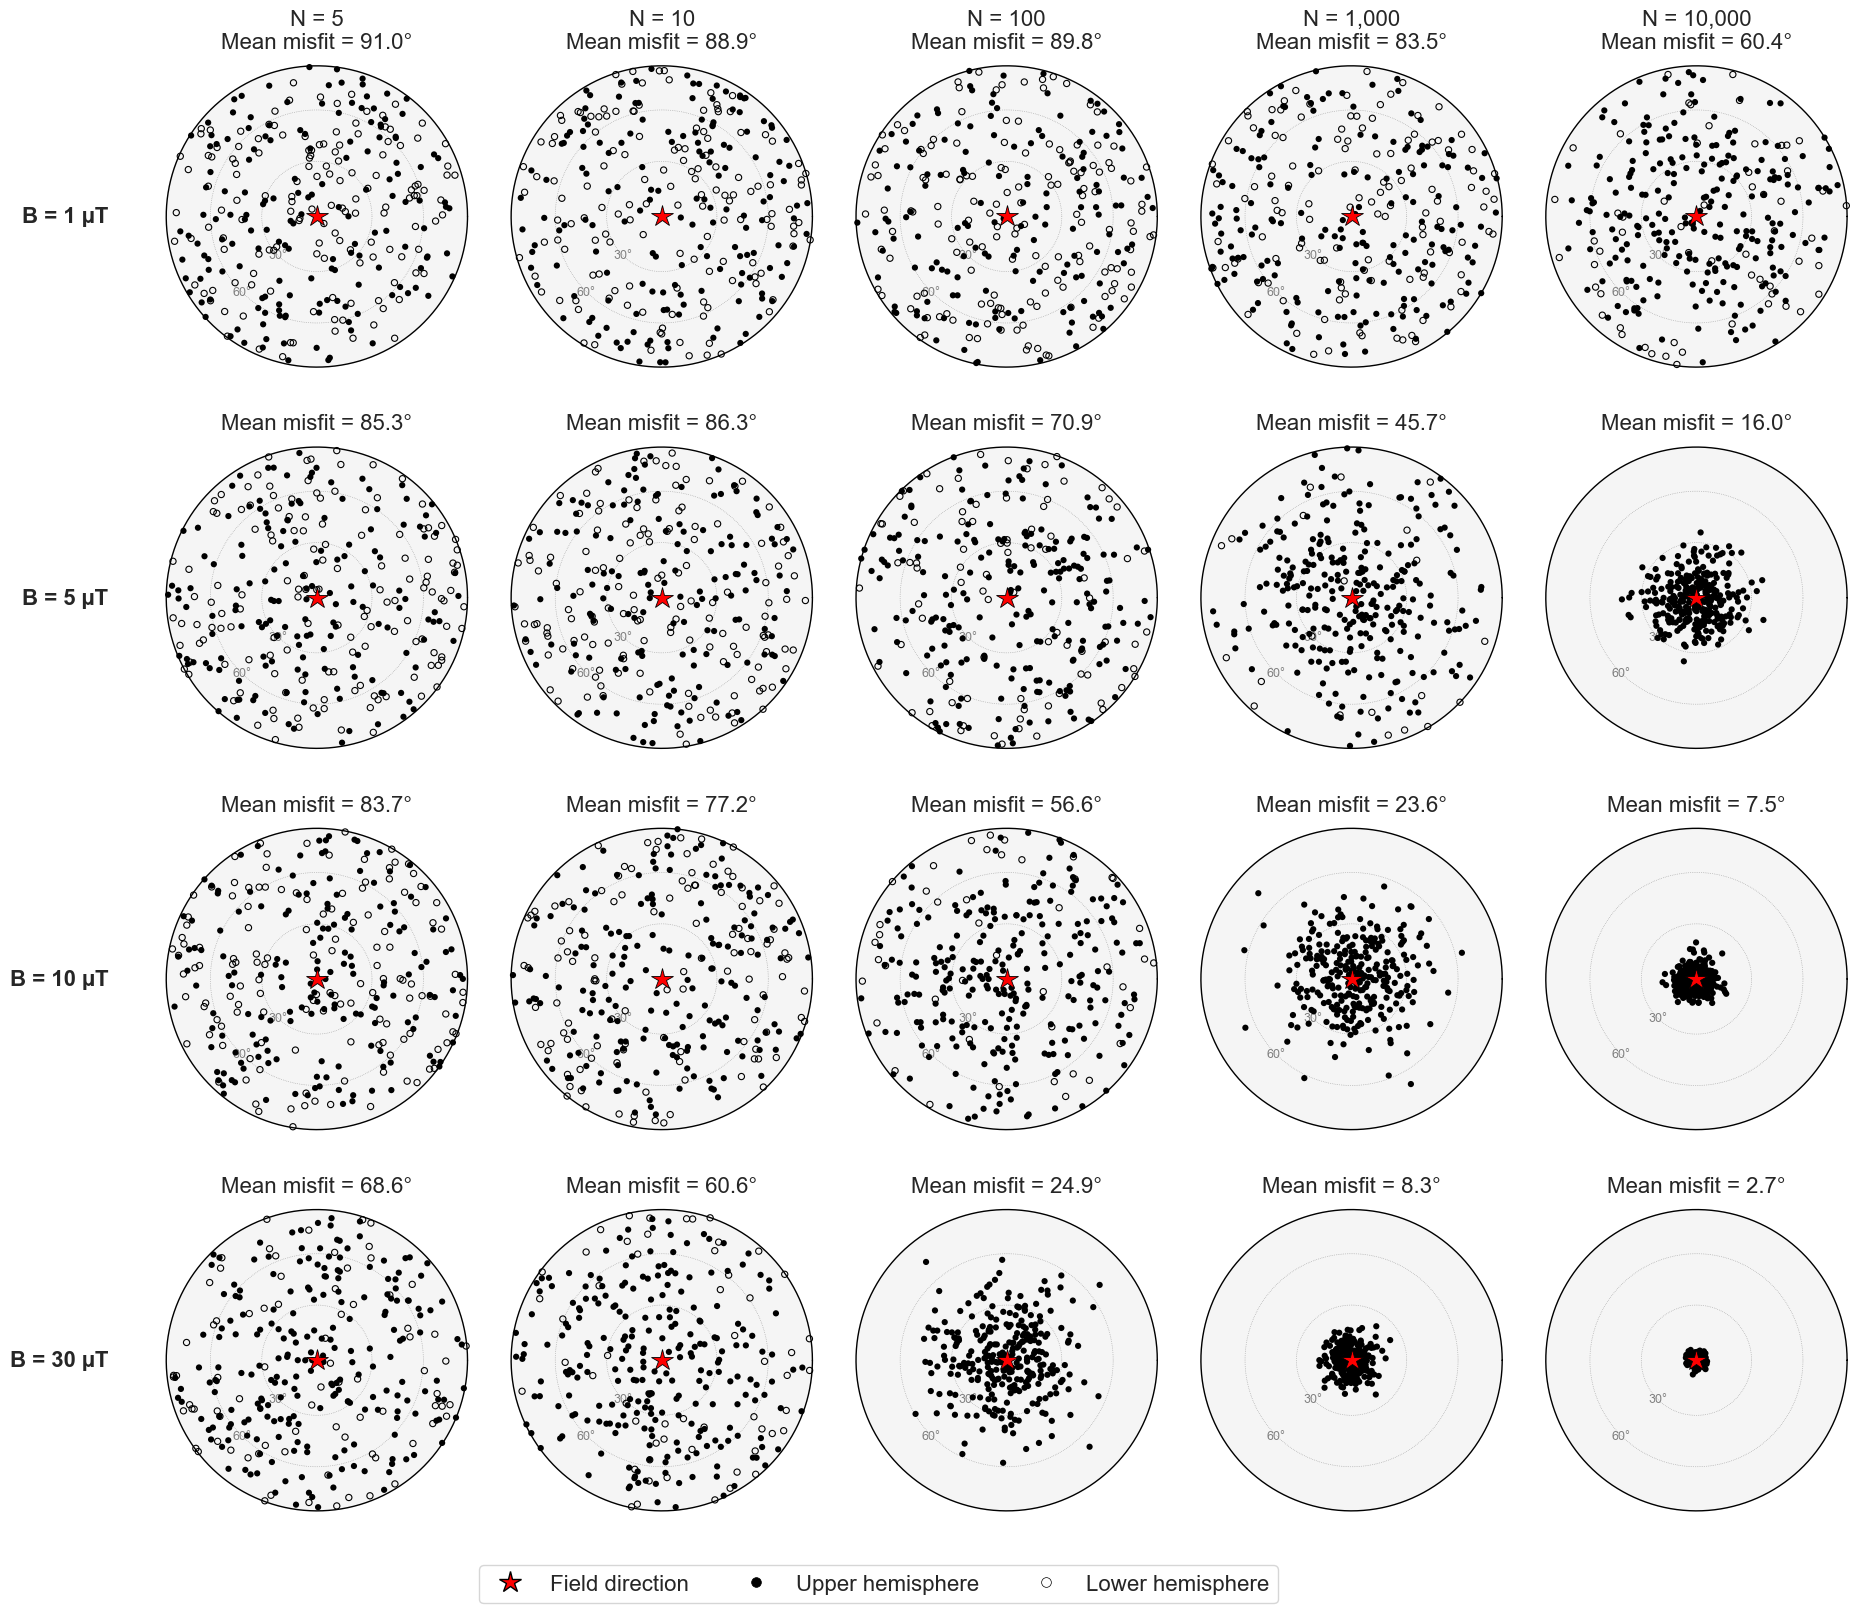

Saved d:\prebiotic_crm\plots_crm_efficiency_mc\crm_eff_mc_stereonet_grid.png


In [18]:
# -- Stereonet grid: scatter of individual realizations, N x B (exact MC) ----
from matplotlib.lines import Line2D

N_STEREO_GRID_MC = [5, 10, 100, 1_000, 10_000]
K_STEREO_MC      = 300

B_ROWS_MC        = [B_1, B_5, B_10, B_MAG]   # 1,5,10,30 uT -- matches crm_efficiency_final.ipynb's B_ROWS
B_LABELS_MC      = [f'B = {B * 1e6:.0f} µT' for B in B_ROWS_MC]

rng_grid_mc    = np.random.default_rng(4242)
n_rows, n_cols = len(B_ROWS_MC), len(N_STEREO_GRID_MC)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 4.0 * n_rows), squeeze=False)
th   = np.linspace(0, 2 * np.pi, 300)
R_eq = np.sqrt(2)
cols_grid_mc = [plt.cm.viridis(v) for v in np.linspace(0.1, 0.9, len(N_STEREO_GRID_MC))]

for row_idx, (B, B_lbl) in enumerate(zip(B_ROWS_MC, B_LABELS_MC)):
    Mp, Mo = _pool_lookup(B)
    M_par_sum, Mx, My = crm.sample_assemblage_moments(
        Mp, Mo, N_STEREO_GRID_MC, K_STEREO_MC, rng_grid_mc)

    for col_idx, (N, col) in enumerate(zip(N_STEREO_GRID_MC, cols_grid_mc)):
        ax = axes[row_idx][col_idx]
        ax.fill(R_eq * np.cos(th), R_eq * np.sin(th), color='#f5f5f5', zorder=0)
        ax.plot(R_eq * np.cos(th), R_eq * np.sin(th), 'k-', lw=1.0, zorder=1)
        for deg in [30, 60]:
            r_ref = 2.0 * np.sin(np.radians(deg / 2.0))
            ax.plot(r_ref * np.cos(th), r_ref * np.sin(th),
                    'k:', lw=0.5, alpha=0.35, zorder=2)
            ax.text(r_ref*np.cos(np.radians(225)), r_ref*np.sin(np.radians(225)),
                                    f'{deg}°', ha='center', va='center', color='0.5', zorder=3, fontsize=9)                  
        ax.plot(0, 0, '*', ms=16, color='r', markeredgecolor='k',
                markeredgewidth=0.6, zorder=10)

        M3d = (M_par_sum[col_idx][:, None] * b_hat_lab
               + Mx[col_idx][:, None] * e1 + My[col_idx][:, None] * e2)
        dirs = M3d / np.linalg.norm(M3d, axis=1, keepdims=True)
        xp, yp, up = crm.ea_project(dirs, b_hat_lab, e1, e2)
        ax.scatter(xp[up], yp[up], s=20, color='k', zorder=5, edgecolors='none')
        ax.scatter(xp[~up], yp[~up], s=20, facecolors='none', edgecolors='k',
                   linewidths=0.8, zorder=5)

        mean_misfit = np.degrees(np.arccos(np.clip(dirs @ b_hat_lab, -1, 1))).mean()
        title = f'N = {N:,}\nMean misfit = {mean_misfit:.1f}°' if row_idx == 0 \
                else f'Mean misfit = {mean_misfit:.1f}°'
        ax.set_title(title, pad=4, fontsize=16)
        if col_idx == 0:
            ax.text(-0.14, 0.5, B_lbl, transform=ax.transAxes,
                    ha='right', va='center', fontweight='bold', fontsize=16)

        ax.set_aspect('equal'); ax.axis('off')
        ax.set_xlim(-R_eq * 1.08, R_eq * 1.08)
        ax.set_ylim(-R_eq * 1.08, R_eq * 1.08)

leg_handles = [Line2D([0], [0], marker='*', color='w', markerfacecolor='r',
                      markeredgecolor='k', markersize=16, label='Field direction'),
               Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
                      markeredgecolor='k', markeredgewidth=0.5, markersize=7,
                      label='Upper hemisphere'),
               Line2D([0], [0], marker='o', color='w', markerfacecolor='w',
                      markeredgecolor='k', markeredgewidth=0.5, markersize=7,
                      label='Lower hemisphere')]
fig.legend(handles=leg_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02),fontsize=16)

plt.tight_layout(rect=[0.06, 0.02, 1, 1])
savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_stereonet_grid.png')
fig.savefig(savepath, dpi=200, bbox_inches='tight')
plt.show(); plt.close(fig)
print(f'Saved {savepath}')


## 9. Comparing $N_{95,10}$ and $N_{\langle\delta\rangle\leq10}$

Both critical-assemblage-size statistics used throughout this notebook come
from the *same* underlying per-assemblage angular-misfit distribution at a
given $(B, N)$ -- they just summarize it differently:

- $N_{\langle\delta\rangle\leq10}$ is the smallest $N$ at which the
  **mean** of that distribution first drops to/under $10^\circ$.
- $N_{95,10}$ is the smallest $N$ at which its **95th percentile** does --
  the point past which at least 95% of individual assemblage draws recover
  the field direction to within $10^\circ$, not just the average draw.

Since the misfit distribution is bounded below at $0^\circ$ and right-skewed
(a few unlucky draws at small $N$ pull the tail out much further than the
bulk), its mean always crosses the $10^\circ$ threshold before its tail
does, so $N_{95,10} \geq N_{\langle\delta\rangle\leq10}$ always. The figure
below makes this concrete at three field intensities: the left column shows
the familiar mean/P95 misfit-vs-N curves with both crossings marked, and the
right column shows the actual misfit distribution at $N$ values bracketing
the transition.


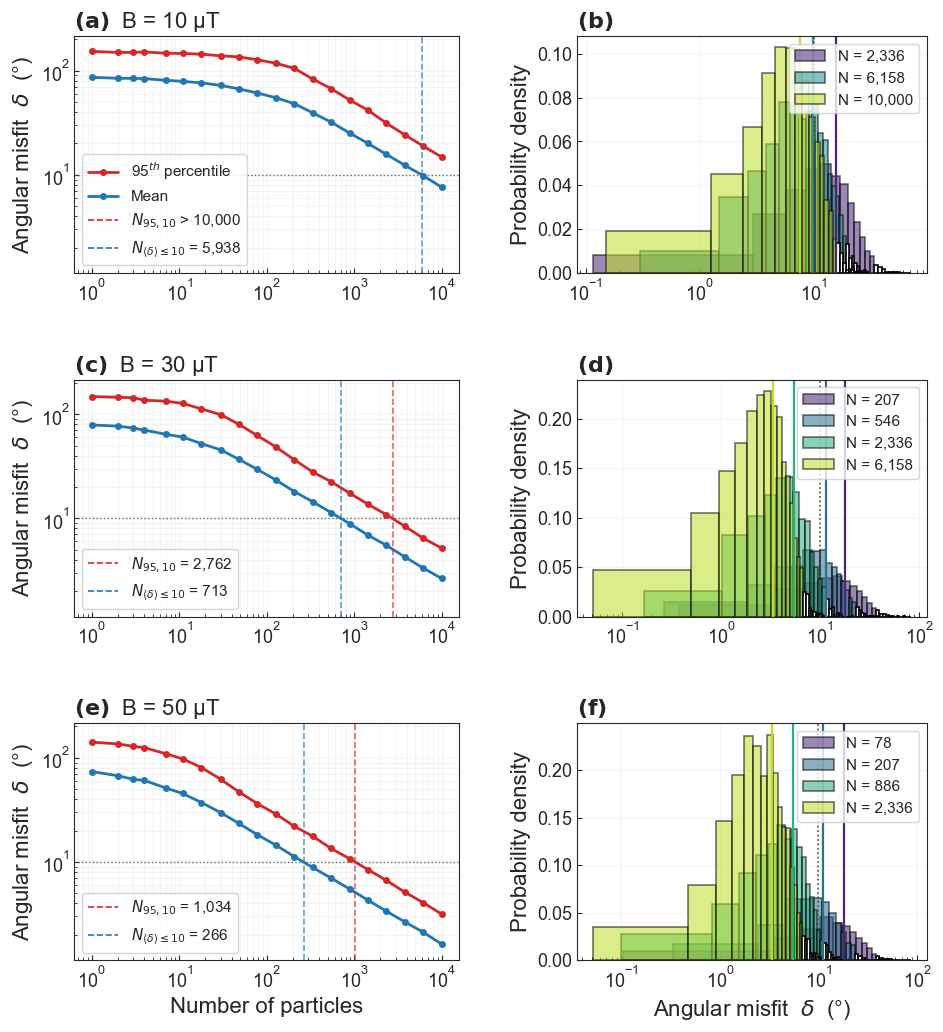

Saved d:\prebiotic_crm\plots_crm_efficiency_mc\crm_eff_mc_N95_vs_Nmean_distributions.png


In [ ]:
# -- Comparing N_{95,10} and N_{delta<=10}: distribution of angular misfit ---
from matplotlib.lines import Line2D

N_GRID_CMP95   = sorted(set(max(1, int(round(x))) for x in np.logspace(0, 4, 20)))
# K_TRIALS_CMP95 = 3000
K_TRIALS_CMP95 = 3000
THRESHOLD_CMP95 = 10.0
N_MAX_CMP95 = N_GRID_CMP95[-1]

rng_cmp95 = np.random.default_rng(1848)

B_ROWS_CMP95    = [B_10, B_MAG, B_50]   # 10, 30, 50 uT (30 uT reuses the S2 reference pool)
PANEL_LETTERS_L = ['a', 'c', 'e']
PANEL_LETTERS_R = ['b', 'd', 'f']

def _fmt_N(val, label):
    # None means the curve never reached the threshold within N_GRID_CMP95,
    # i.e. the true crossing lies beyond the grid's own max N.
    if val is None:
        return f'{label} > {N_MAX_CMP95:,.0f}'
    return f'{label} = {val:,.0f}'

# -- pass 1: compute all three fields' data first, so the left column can ---
# -- share one y-axis range --------------------------------------------------
rows_data = []
for B in B_ROWS_CMP95:
    Mp, Mo = _pool_lookup(B)
    M_par_sum, Mx, My = crm.sample_assemblage_moments(Mp, Mo, N_GRID_CMP95, K_TRIALS_CMP95, rng_cmp95)
    misfit_arr = crm.angular_misfit(M_par_sum, Mx, My)      # (len(N_GRID_CMP95), K_TRIALS_CMP95)
    mean_curve = misfit_arr.mean(axis=1)
    p95_curve  = np.percentile(misfit_arr, 95, axis=1)
    N_mean_cross = crm.find_log_intersection(N_GRID_CMP95, mean_curve, THRESHOLD_CMP95)
    N_p95_cross  = crm.find_log_intersection(N_GRID_CMP95, p95_curve,  THRESHOLD_CMP95)
    rows_data.append(dict(B=B, misfit_arr=misfit_arr, mean_curve=mean_curve, p95_curve=p95_curve,
                           N_mean_cross=N_mean_cross, N_p95_cross=N_p95_cross))

y_all = np.concatenate([np.concatenate([r['mean_curve'], r['p95_curve']]) for r in rows_data])
y_all = y_all[np.isfinite(y_all) & (y_all > 0)]
Y_LO, Y_HI = y_all.min() * 0.7, y_all.max() * 1.4

fig = plt.figure(figsize=(11, 12))
gs = fig.add_gridspec(len(B_ROWS_CMP95), 2, hspace=0.45, wspace=0.32, width_ratios=[1.1, 1])

for row, r in enumerate(rows_data):
    B, misfit_arr           = r['B'], r['misfit_arr']
    mean_curve, p95_curve   = r['mean_curve'], r['p95_curve']
    N_mean_cross, N_p95_cross = r['N_mean_cross'], r['N_p95_cross']

    # -- left: misfit-vs-N curve with the two crossings marked --------------
    ax_l = fig.add_subplot(gs[row, 0])
    lbl_p95  = r'95$^{th}$ percentile' if row == 0 else None
    lbl_mean = 'Mean' if row == 0 else None
    ax_l.plot(N_GRID_CMP95, p95_curve,  color='tab:red',  lw=2.0, marker='o', ms=4, label=lbl_p95)
    ax_l.plot(N_GRID_CMP95, mean_curve, color='tab:blue', lw=2.0, marker='o', ms=4, label=lbl_mean)
    ax_l.axhline(THRESHOLD_CMP95, color='0.4', ls=':', lw=1.0)
    if N_mean_cross is not None:
        ax_l.axvline(N_mean_cross, color='tab:blue', ls='--', lw=1.2, alpha=0.7)
    if N_p95_cross is not None:
        ax_l.axvline(N_p95_cross, color='tab:red', ls='--', lw=1.2, alpha=0.7)

    # N-crossing legend entries (styled to match the vertical marker lines)
    h_p95  = Line2D([0], [0], color='tab:red',  ls='--', lw=1.2,
                    label=_fmt_N(N_p95_cross,  r'$N_{95,10}$'))
    h_mean = Line2D([0], [0], color='tab:blue', ls='--', lw=1.2,
                    label=_fmt_N(N_mean_cross, r'$N_{\langle\delta\rangle\leq10}$'))

    ax_l.set_xscale('log'); ax_l.set_yscale('log')
    ax_l.set_ylim(Y_LO, Y_HI)
    if row==2:
        ax_l.set_xlabel('Number of particles')
    ax_l.set_ylabel(r'Angular misfit  $\delta$  (°)')
    ax_l.set_title(r'$\mathbf{(%s)}$  B = %g µT' % (PANEL_LETTERS_L[row], B * 1e6),
                   loc='left')

    if row == 0:
        curve_handles, _ = ax_l.get_legend_handles_labels()
        ax_l.legend(handles=curve_handles + [h_p95, h_mean], loc='lower left')
    else:
        ax_l.legend(handles=[h_p95, h_mean], loc='lower left')
    ax_l.grid(True, which='both', alpha=0.2)

    # -- right: distribution snapshots at N's bracketing the transition -----
    ax_r = fig.add_subplot(gs[row, 1])
    N_arr = np.array(N_GRID_CMP95, dtype=float)
    disp_idx = []
    if N_mean_cross is not None:
        disp_idx.append(int(np.argmin(np.abs(N_arr - N_mean_cross))))
    if N_p95_cross is not None:
        disp_idx.append(int(np.argmin(np.abs(N_arr - N_p95_cross))))
    if disp_idx:
        lo = max(0, min(disp_idx) - 2)
        hi = min(len(N_GRID_CMP95) - 1, max(disp_idx) + 2)
        disp_idx = sorted(set(disp_idx + [lo, hi]))
    else:
        disp_idx = [0, len(N_GRID_CMP95) // 2, len(N_GRID_CMP95) - 1]

    cols_disp = plt.cm.viridis(np.linspace(0.1, 0.9, len(disp_idx)))
    for ci, ni in zip(cols_disp, disp_idx):
        N_i    = N_GRID_CMP95[ni]
        data_i = misfit_arr[ni]
        p95_i  = np.percentile(data_i, 95)
        mean_i = data_i.mean()

        # Color the bulk (<=95th percentile); leave the 5% tail beyond it white.
        _, bins_i, patches_i = ax_r.hist(data_i, bins=25, density=True, color=ci,
                                          edgecolor='k', alpha=0.55, lw=1.2, label=f'N = {N_i:,}')
        for patch, left_edge in zip(patches_i, bins_i[:-1]):
            if left_edge >= p95_i:
                patch.set_facecolor('white')
                patch.set_alpha(1.0)
        ax_r.axvline(mean_i, color=ci, lw=1.6, ls='-')

    ax_r.axvline(THRESHOLD_CMP95, color='0.3', ls=':', lw=1.2)
    if row==2:
        ax_r.set_xlabel(r'Angular misfit  $\delta$  (°)')
    ax_r.set_ylabel('Probability density')
    ax_r.set_title(r'$\mathbf{(%s)}$' % PANEL_LETTERS_R[row], loc='left')
    ax_r.legend(fontsize=8, loc='upper right')
    ax_r.grid(True, alpha=0.2)
    ax_r.set_xticks(range(0,90,10),range(0,90,10))

savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_N95_vs_Nmean_distributions.png')
fig.savefig(savepath, dpi=200, bbox_inches='tight')
plt.show(); plt.close(fig)
print(f'Saved {savepath}')


## 10. Generator matrix through growth

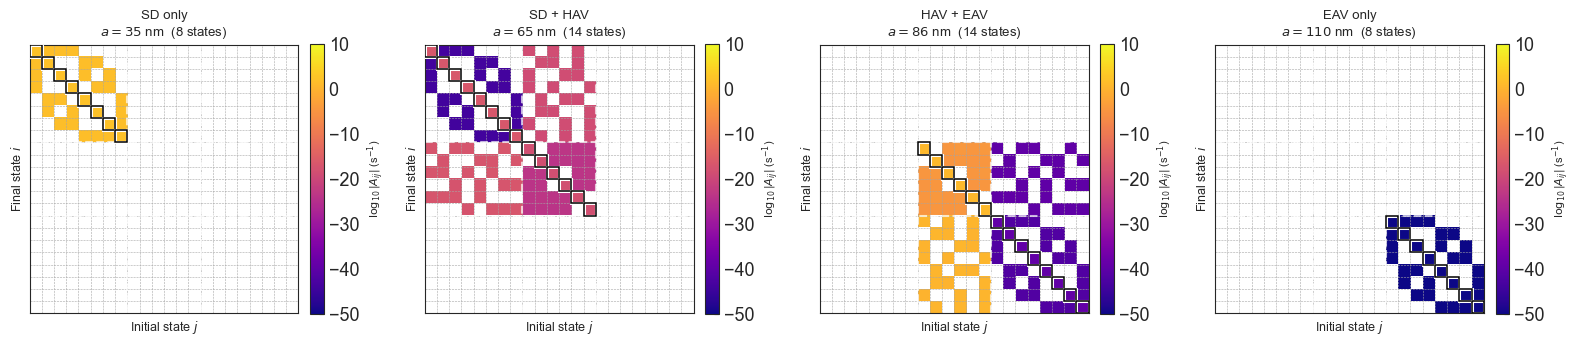

Saved d:\prebiotic_crm\plots_crm_efficiency_mc\crm_eff_mc_generator_matrix_through_growth.png


In [63]:
# -- Generator matrix through growth: fixed 22-state grid --------------------
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe

STATE_ORDER_22 = [('SD', i) for i in range(8)] + [('HAV', i) for i in range(6)] + [('EAV', i) for i in range(8)]
STATE_IDX_22   = {s: i for i, s in enumerate(STATE_ORDER_22)}
N_STATES_22    = len(STATE_ORDER_22)   # 22

B_ex_gen = B_MAG * crm._n([1, 1, 1])

examples_gen = [
    (35,  'SD only\n$a = 35$ nm  (8 states)'),
    (65,  'SD + HAV\n$a = 65$ nm  (14 states)'),
    (86,  'HAV + EAV\n$a = 86$ nm  (14 states)'),
    (110, 'EAV only\n$a = 110$ nm  (8 states)'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5.5))
cmap_gen = plt.cm.plasma.copy()
cmap_gen.set_bad('white')

for ax, (s_ex, title) in zip(axes, examples_gen):
    states_ex = crm.active_states(s_ex)
    b_ex      = fine_all_barriers[s_ex]
    A         = crm.build_generator(states_ex, b_ex, B_ex_gen, s_ex)

    disp = np.full((N_STATES_22, N_STATES_22), np.nan)
    idx_map = [STATE_IDX_22[s] for s in states_ex]
    for i_local, i_glob in enumerate(idx_map):
        for j_local, j_glob in enumerate(idx_map):
            if abs(A[i_local, j_local]) > 1e-300:
                disp[i_glob, j_glob] = np.log10(abs(A[i_local, j_local]))

    im = ax.imshow(disp, cmap=cmap_gen, vmin=-50, vmax=10,
                   aspect='auto', interpolation='nearest', zorder=0)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(r'$\log_{10}|A_{ij}|$ (s$^{-1}$)', fontsize=8)

    # Full 22x22 cell grid, always visible (even over blank/inactive cells)
    for k in range(N_STATES_22 + 1):
        ax.axhline(k - 0.5, color='0.65', lw=0.4, ls='--', zorder=1)
        ax.axvline(k - 0.5, color='0.65', lw=0.4, ls='--', zorder=1)

    for boundary in [8, 14]:
        ax.axhline(boundary - 0.5, color='white', lw=1.5, ls='--', alpha=0.7, zorder=2)
        ax.axvline(boundary - 0.5, color='white', lw=1.5, ls='--', alpha=0.7, zorder=2)

    # Outline diagonal cells: A_ii = -sum_{j!=i} k_{i->j} is a total outflow
    # rate (aggregate over every outgoing channel), not a single pairwise
    # rate like the off-diagonal cells -- flag it structurally rather than
    # with a second color scale, so it stays directly comparable in
    # magnitude via the one colorbar.
    for i_glob in idx_map:
        rect = Rectangle((i_glob - 0.5, i_glob - 0.5), 1, 1, fill=False,
                         edgecolor='black', linewidth=1.1, zorder=3)
        rect.set_path_effects([pe.withStroke(linewidth=2.2, foreground='white')])
        ax.add_patch(rect)
    # for lo, hi, t in [(0, 8, 'SD'), (8, 14, 'HAV'), (14, 22, 'EAV')]:
        # ax.text((lo + hi) / 2 - 0.5, N_STATES_22 + 0.3, t, ha='center', va='bottom',
        #         fontsize=8, fontweight='bold',
        #         color={'SD': '#d73027', 'HAV': '#4575b4', 'EAV': '#1a9641'}[t],
        #         transform=ax.transData)

    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel('Initial state $j$', fontsize=9)
    ax.set_ylabel('Final state $i$', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(-0.5, N_STATES_22 - 0.5)
    ax.set_ylim(N_STATES_22 - 0.5, -0.5)
    ax.set_aspect('equal')

plt.tight_layout()
savepath = os.path.join(PLOTS_DIR, 'crm_eff_mc_generator_matrix_through_growth.png')
fig.savefig(savepath, dpi=200, bbox_inches='tight')
plt.show(); plt.close(fig)
print(f'Saved {savepath}')


In [65]:
# -- Animation: generator matrix through growth (every fine-grid size) ------
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe

def _state_label_anim(types):
    order = ['SD', 'HAV', 'EAV']
    present = [t for t in order if t in types]
    return ' + '.join(present) + (' only' if len(present) == 1 else '')

def _frame_disp(size):
    states_ex = crm.active_states(size)
    b_ex      = fine_all_barriers[size]
    A         = crm.build_generator(states_ex, b_ex, B_ex_gen, size)
    disp = np.full((N_STATES_22, N_STATES_22), np.nan)
    idx_map = [STATE_IDX_22[s] for s in states_ex]
    for i_local, i_glob in enumerate(idx_map):
        for j_local, j_glob in enumerate(idx_map):
            if abs(A[i_local, j_local]) > 1e-300:
                disp[i_glob, j_glob] = np.log10(abs(A[i_local, j_local]))
    return disp, states_ex

fig_anim, ax_anim = plt.subplots(figsize=(5.5, 5.5))
im_anim = ax_anim.imshow(np.full((N_STATES_22, N_STATES_22), np.nan), cmap=cmap_gen,
                         vmin=-50, vmax=10, aspect='auto', interpolation='nearest', zorder=0)
cb_anim = plt.colorbar(im_anim, ax=ax_anim, fraction=0.046, pad=0.04)
cb_anim.set_label(r'$\log_{10}|A_{ij}|$ (s$^{-1}$)', fontsize=9)

for k in range(N_STATES_22 + 1):
    ax_anim.axhline(k - 0.5, color='0.65', lw=0.4, ls='--', zorder=1)
    ax_anim.axvline(k - 0.5, color='0.65', lw=0.4, ls='--', zorder=1)
for boundary in [8, 14]:
    ax_anim.axhline(boundary - 0.5, color='white', lw=1.5, ls='--', alpha=0.7, zorder=2)
    ax_anim.axvline(boundary - 0.5, color='white', lw=1.5, ls='--', alpha=0.7, zorder=2)

ax_anim.set_xlabel('Initial state $j$', fontsize=10)
ax_anim.set_ylabel('Final state $i$', fontsize=10)
ax_anim.set_xticks([]); ax_anim.set_yticks([])
ax_anim.set_xlim(-0.5, N_STATES_22 - 0.5)
ax_anim.set_ylim(N_STATES_22 - 0.5, -0.5)
ax_anim.set_aspect('equal')
title_anim = ax_anim.set_title('', fontsize=11)
diag_patches = []   # outlines for the current frame's diagonal cells

FINE_SIZES_ANIM = [s for s in FINE_SIZES if s <= 110]   # stop at 110 nm --
                                                          # EAV is already
                                                          # fully blocked
                                                          # (A == 0 exactly)
                                                          # well before 200 nm

def _update(frame_i):
    size = FINE_SIZES_ANIM[frame_i]
    disp, states_ex = _frame_disp(size)
    im_anim.set_data(disp)

    for p in diag_patches:
        p.remove()
    diag_patches.clear()
    idx_map = [STATE_IDX_22[s] for s in states_ex]
    for i_glob in idx_map:
        rect = Rectangle((i_glob - 0.5, i_glob - 0.5), 1, 1, fill=False,
                         edgecolor='black', linewidth=1.1, zorder=3)
        rect.set_path_effects([pe.withStroke(linewidth=2.2, foreground='white')])
        ax_anim.add_patch(rect)
        diag_patches.append(rect)

    types_here = {t for t, _ in states_ex}
    is_last  = frame_i == len(FINE_SIZES_ANIM) - 1
    size_str = f'\u2265 {size} nm' if is_last else f'= {size} nm'
    title_anim.set_text(f'{_state_label_anim(types_here)}, size {size_str}')
    return im_anim, title_anim, *diag_patches

ani = FuncAnimation(fig_anim, _update, frames=len(FINE_SIZES_ANIM), blit=False)
savepath_anim = os.path.join(PLOTS_DIR, 'crm_eff_mc_generator_matrix_animation.gif')
ani.save(savepath_anim, writer=PillowWriter(fps=1))
plt.close(fig_anim)
print(f'Saved {savepath_anim}  ({len(FINE_SIZES_ANIM)} frames)')


Saved d:\prebiotic_crm\plots_crm_efficiency_mc\crm_eff_mc_generator_matrix_animation.gif  (91 frames)
